In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("/content/OnlineRetail.csv",encoding="latin1")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [5]:
df.shape

(541909, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [9]:
df[df["CustomerID"].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom


Percentage of Customer ID data

In [10]:
missing_customer_percent = (
    df["CustomerID"].isnull().mean() * 100
)

print(missing_customer_percent)

24.926694334288598


how many customers exist

In [11]:
df["CustomerID"].nunique()

4372

How many orders were placed

In [12]:
df["InvoiceNo"].nunique()

25900

How many different products are sold

In [13]:
df["StockCode"].nunique()

4070

Countries which contributes more sales

In [14]:
df["Country"].value_counts()

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


Checking for negative quantities which represent product returns or cancelled

In [15]:
df[df["Quantity"]<0].value_counts()


InvoiceNo  StockCode  Description                         Quantity  InvoiceDate       UnitPrice  CustomerID  Country       
C543611    82483      WOOD 2 DRAWER CABINET WHITE FINISH  -1        2/10/2011 14:38   4.95       17850.0     United Kingdom    4
C538341    22730      ALARM CLOCK BAKELIKE IVORY          -1        12/10/2010 14:03  3.75       15514.0     United Kingdom    3
           22725      ALARM CLOCK BAKELIKE CHOCOLATE      -1        12/10/2010 14:03  3.75       15514.0     United Kingdom    3
           22976      CIRCUS PARADE CHILDRENS EGG CUP     -12       12/10/2010 14:03  1.25       15514.0     United Kingdom    3
C550165    22962      JAM JAR WITH PINK LID               -1        4/14/2011 16:34   0.85       15358.0     United Kingdom    2
                                                                                                                              ..
C551464    22745      POPPY'S PLAYHOUSE BEDROOM           -6        4/28/2011 16:15   2.10       13085.0     United Kingdom    1
           22746      POPPY'S PLAYHOUSE LIVINGROOM        -6        4/28/2011 16:15   2.10       13085.0     United Kingdom    1
           22748      POPPY'S PLAYHOUSE KITCHEN           -6        4/28/2011 16:15   2.10       13085.0     United Kingdom    1
C551465    21714      CITRONELLA CANDLE GARDEN POT        -3        4/28/2011 16:17   1.25       14640.0     United Kingdom    1
C551463    23152      IVORY SWEETHEART WIRE LETTER RACK   -2        4/28/2011 16:13   3.75       13534.0     United Kingdom    1
Name: count, Length: 8872, dtype: int64

In [16]:
(df['Quantity']<0).sum()

np.int64(10624)

Invoice Cancellation rows

In [17]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

Unique Cancellation Invoices

In [18]:
df[df["InvoiceNo"].astype(str).str.startswith("C")]["InvoiceNo"].nunique()

3836

Data Cleaning

In [19]:
df.duplicated().sum()

np.int64(5268)

In [20]:
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

In [21]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [22]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [23]:
df = df[
    (df["CustomerID"].notnull()) &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

In [24]:
df.shape


(397884, 8)

In [25]:
duplicates = df.duplicated().sum()
print(duplicates)

5192


In [26]:
df[df.duplicated()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [27]:
#total spent
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [28]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


Exploratory Data Analysis

In [29]:
df["Revenue"].sum()

np.float64(8911407.904)

Top Countries

In [30]:
top_countries=(
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)

)
top_countries.head(10)

,Revenue
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


Top Customers

In [31]:
top_customers=(
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)

)
top_customers.head(10)


,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194550.79
16446.0,168472.50
14911.0,143825.06
12415.0,124914.53
14156.0,117379.63
17511.0,91062.38
16029.0,81024.84


Most Frequent Customers

In [32]:
customer_orders=(
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)
customer_orders.head(10)

,InvoiceNo
CustomerID,
12748.0,209
14911.0,201
17841.0,124
13089.0,97
14606.0,93
15311.0,91
12971.0,86
14646.0,73
16029.0,63


Best Selling Products

In [33]:
best_products=(
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)
best_products.head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
JUMBO BAG RED RETROSPOT,46181
WHITE HANGING HEART T-LIGHT HOLDER,36725
ASSORTED COLOUR BIRD ORNAMENT,35362
PACK OF 72 RETROSPOT CAKE CASES,33693
POPCORN HOLDER,30931
RABBIT NIGHT LIGHT,27202


Highest Revenue Products

In [34]:
highest_revenue_products=(
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
highest_revenue_products.head(10)

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142592.95
WHITE HANGING HEART T-LIGHT HOLDER,100448.15
JUMBO BAG RED RETROSPOT,85220.78
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68844.33
ASSORTED COLOUR BIRD ORNAMENT,56580.34
Manual,53779.93


In [35]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["YearMonth"]=(
    df["InvoiceDate"]
    .dt.to_period("M")
    .astype(str)
)

In [36]:
montly_revenue=(
    df.groupby("YearMonth")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
montly_revenue.head(10)

,Revenue
YearMonth,
2011-11,1161817.380
2011-10,1039318.790
2011-09,952838.382
2011-05,678594.560
2011-06,661213.690
2011-08,645343.900
2011-07,600091.011
2011-03,595500.760
2010-12,572713.890


In [37]:
customer_summary = (
    df.groupby("CustomerID")
    .agg({
        "Revenue": "sum",
        "InvoiceNo": "nunique",
        "Quantity": "sum"
    })
)
customer_summary.head(10)

,Revenue,InvoiceNo,Quantity
CustomerID,,,
12346.0,77183.60,1,74215
12347.0,4310.00,7,2458
12348.0,1797.24,4,2341
12349.0,1757.55,1,631
12350.0,334.40,1,197
12352.0,2506.04,8,536
12353.0,89.00,1,20
12354.0,1079.40,1,530
12355.0,459.40,1,240


RFM Analysis

In [38]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [39]:
snapshot_date=df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [40]:
rfm=(
    df.groupby("CustomerID")
    .agg({
        "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
        "InvoiceNo": "nunique",
        "Revenue": "sum"
    })
)
rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm["Frequency"] = np.log1p(rfm["Frequency"])
rfm["Monetary"] = np.log1p(rfm["Monetary"])
rfm.head(10)

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,0.693147,11.253955
12347.0,2,2.079442,8.368925
12348.0,75,1.609438,7.494564
12349.0,19,0.693147,7.472245
12350.0,310,0.693147,5.815324
12352.0,36,2.197225,7.826858
12353.0,204,0.693147,4.499810
12354.0,232,0.693147,6.985087
12355.0,214,0.693147,6.132096


In [41]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,1.345582,6.593627
std,100.014169,0.683104,1.257578
min,1.000000,0.693147,1.558145
25%,18.000000,0.693147,5.731446
50%,51.000000,1.098612,6.515431
75%,142.000000,1.791759,7.416222
max,374.000000,5.347108,12.543284


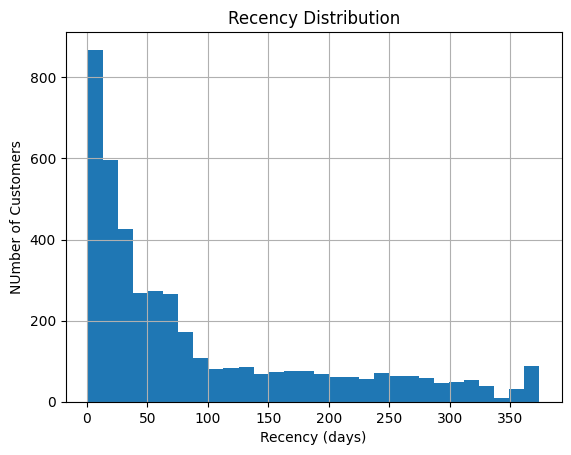

In [42]:
rfm["Recency"].hist(bins=30)
plt.title("Recency Distribution")
plt.xlabel("Recency (days)")
plt.ylabel("NUmber of Customers")
plt.show()

Most customers made purchases within the last 100 days, while a smaller group has been inactive for several months

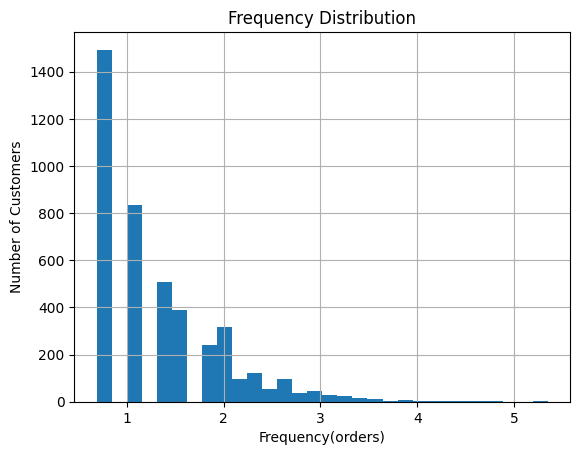

In [43]:
rfm["Frequency"].hist(bins=30)
plt.title("Frequency Distribution")
plt.xlabel("Frequency(orders)")
plt.ylabel("Number of Customers")
plt.show()

The majority of customers place only a few orders, while a small number of highly engaged customers account for a large number of transactions.

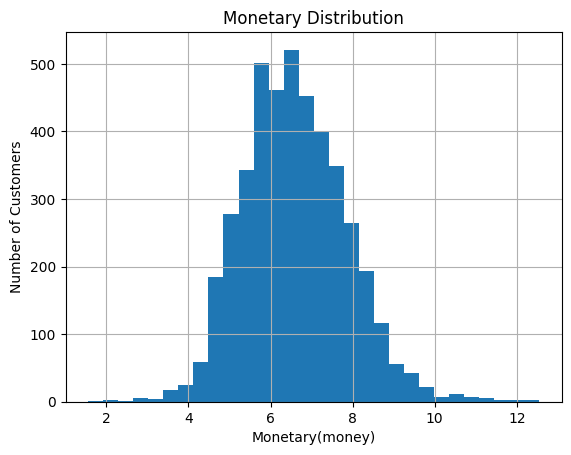

In [44]:
rfm["Monetary"].hist(bins=30)
plt.title("Monetary Distribution")
plt.xlabel("Monetary(money)")
plt.ylabel("Number of Customers")
plt.show()

Most of the customers spend small amounts, while a tiny group of big-spending  customers generates massive revenue for the business.

In [45]:

rfm["Frequency"] = np.log1p(rfm["Frequency"])
rfm["Monetary"] = np.log1p(rfm["Monetary"])
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,0.814870,2.013529
std,100.014169,0.267858,0.167083
min,1.000000,0.526589,0.939282
25%,18.000000,0.526589,1.906790
50%,51.000000,0.741276,2.016958
75%,142.000000,1.026672,2.130161
max,374.000000,1.847999,2.605891


Log transformation successfully normalized Frequency and Monetary variables, making them more suitable for clustering and reducing the influence of extreme customer behavior.

<Axes: >

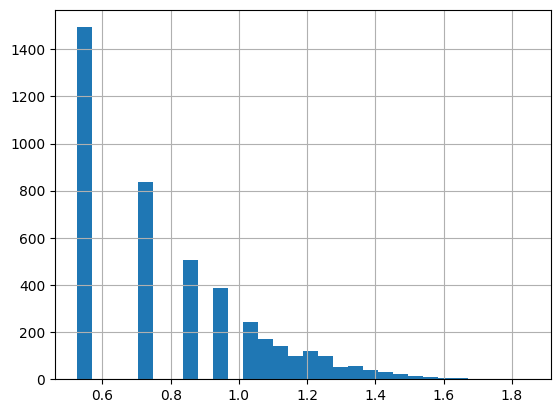

In [46]:
rfm["Frequency"].hist(bins=30)

<Axes: >

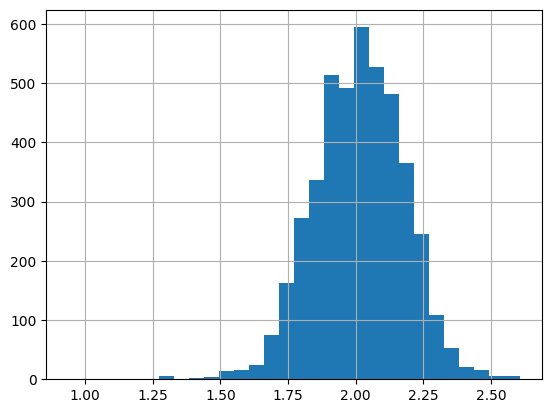

In [47]:
rfm["Monetary"].hist(bins=30)

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

In [49]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

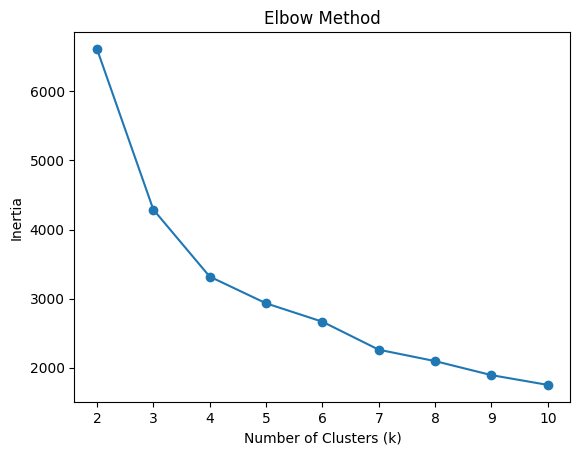

In [50]:
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [51]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [52]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
})

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,59.504762,0.582976,1.872520
1,23.632258,1.204473,2.221623
2,264.611299,0.587244,1.881702
3,56.200950,0.870950,2.061863


In [53]:
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [54]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": ["mean", "median"],
    "Frequency": ["mean", "median"],
    "Monetary": ["mean", "median"]
})

cluster_summary

Recency        Frequency            Monetary          
               mean median      mean    median      mean    median
Cluster                                                           
0         59.504762   52.0  0.582976  0.526589  1.872520  1.892987
1         23.632258   13.0  1.204473  1.162283  2.221623  2.209353
2        264.611299  262.0  0.587244  0.526589  1.881702  1.898324
3         56.200950   40.0  0.870950  0.869742  2.061863  2.060039

In [55]:
rfm["Cluster"].value_counts()

,count
Cluster,
3,1473
0,1050
1,930
2,885


<Axes: xlabel='Cluster'>

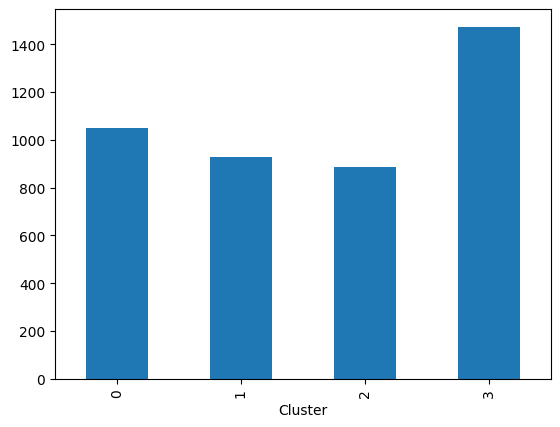

In [56]:
rfm["Cluster"].value_counts().sort_index().plot(kind="bar")

<Axes: xlabel='Cluster'>

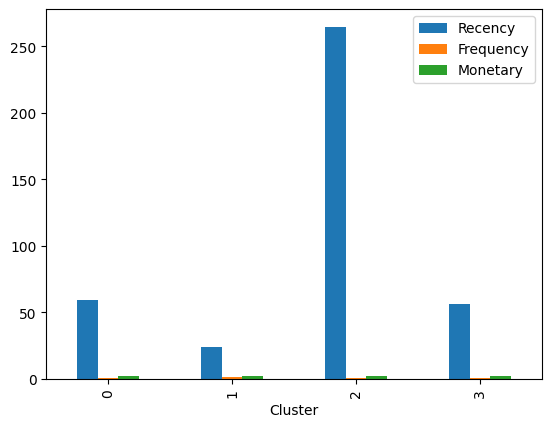

In [57]:
cluster_means = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
cluster_means.plot(kind="bar")

In [58]:
segment_map = {
    0: "Potential Loyalists",
    1: "Champions",
    2: "Lost Customers",
    3: "Loyal Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_map)

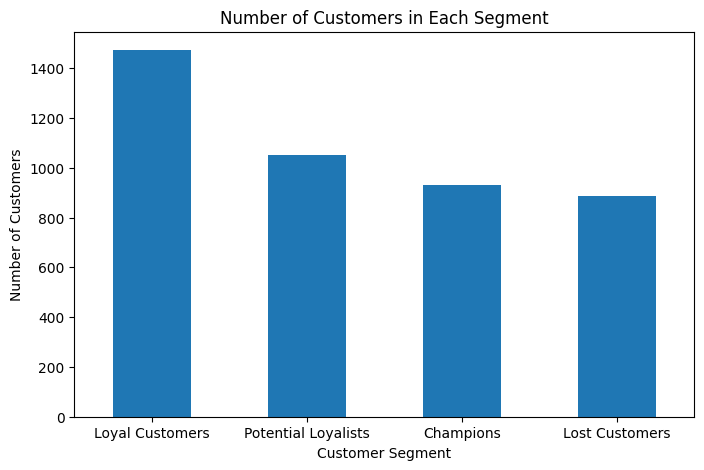

In [59]:
rfm["Segment"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

Loyal Customers represent the largest customer segment, indicating a stable customer base with consistent purchasing behavior.

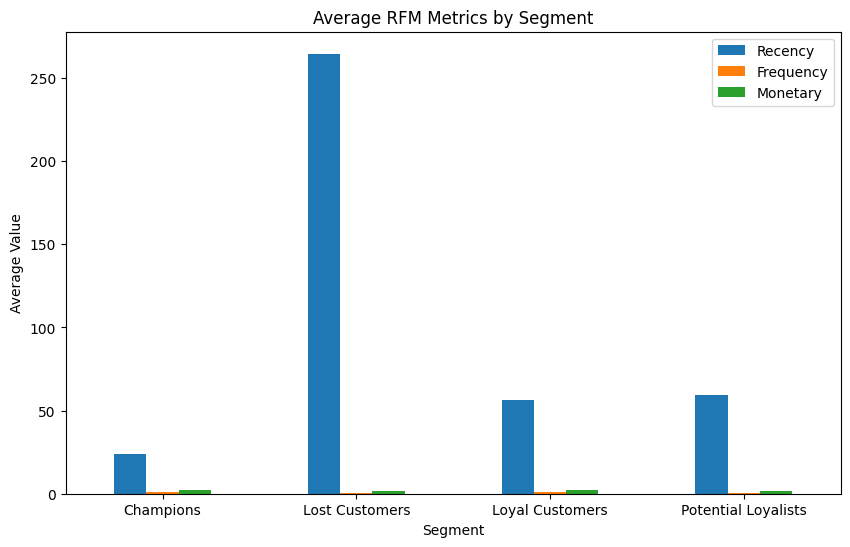

In [61]:
segment_summary = rfm.groupby("Segment")[
    ["Recency","Frequency","Monetary"]
].mean()

segment_summary.plot(kind="bar", figsize=(10,6))

plt.title("Average RFM Metrics by Segment")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

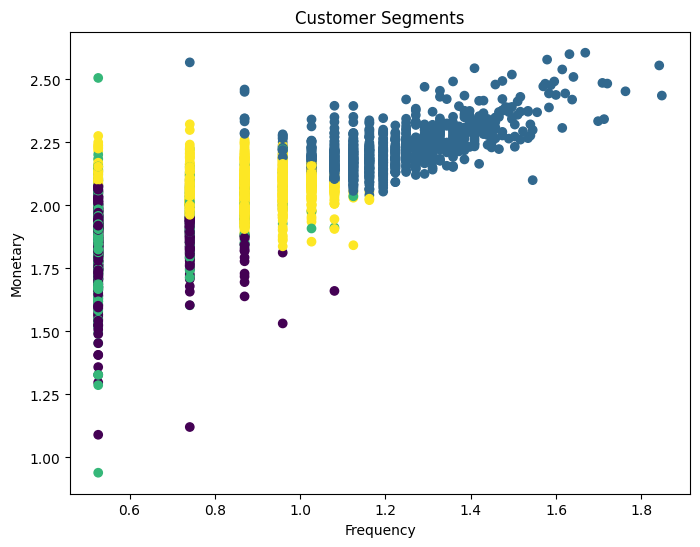

In [62]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segments")
plt.show()

Customers in the upper-right region exhibit both high purchase frequency and high spending, representing the business's most valuable customers.

CHURN PREDICTION

In [80]:
split_date = "2011-09-01"
history_df = df[df["InvoiceDate"] < split_date].copy()

future_df = df[df["InvoiceDate"] >= split_date].copy()

In [81]:
print(history_df.shape)
print(future_df.shape)

(226467, 10)
(171417, 10)


Number of unique orders placed by each customer.

In [83]:
frequency = history_df.groupby("CustomerID")["InvoiceNo"].nunique()
print(frequency)

CustomerID
12346.0    1
12347.0    5
12348.0    3
12350.0    1
12352.0    5
          ..
18280.0    1
18281.0    1
18282.0    1
18283.0    9
18287.0    1
Name: InvoiceNo, Length: 3317, dtype: int64


Total amount spent before the split date.

In [85]:
monetary = history_df.groupby("CustomerID")["Revenue"].sum()
print(monetary)

CustomerID
12346.0    77183.60
12347.0     2790.86
12348.0     1487.24
12350.0      334.40
12352.0     1561.81
             ...   
18280.0      180.60
18281.0       80.82
18282.0      100.21
18283.0      985.77
18287.0      765.28
Name: Revenue, Length: 3317, dtype: float64


Total items purchased.

In [87]:
quantity = history_df.groupby("CustomerID")["Quantity"].sum()
print(quantity)

CustomerID
12346.0    74215
12347.0     1590
12348.0     2124
12350.0      197
12352.0      254
           ...  
18280.0       45
18281.0       54
18282.0       75
18283.0      647
18287.0      488
Name: Quantity, Length: 3317, dtype: int64


Product variety. Customers buying many different products may be more engaged.

In [89]:
products = history_df.groupby("CustomerID")["StockCode"].nunique()
print(products)

CustomerID
12346.0      1
12347.0     82
12348.0     22
12350.0     17
12352.0     26
          ... 
18280.0     10
18281.0      7
18282.0      7
18283.0    183
18287.0     27
Name: StockCode, Length: 3317, dtype: int64


In [92]:
invoice_value = (
    history_df
    .groupby(["CustomerID", "InvoiceNo"])["Revenue"]
    .sum()
)


In [93]:
avg_order = invoice_value.groupby("CustomerID").mean()

In [94]:
features = pd.concat(
    [frequency, monetary, quantity, products, avg_order],
    axis=1
)

In [96]:
features.columns = [
    "Frequency",
    "Monetary",
    "Quantity",
    "UniqueProducts",
    "AvgOrderValue"
]
features.head()

,Frequency,Monetary,Quantity,UniqueProducts,AvgOrderValue
CustomerID,,,,,
12346.0,1,77183.60,74215,1,77183.600000
12347.0,5,2790.86,1590,82,558.172000
12348.0,3,1487.24,2124,22,495.746667
12350.0,1,334.40,197,17,334.400000
12352.0,5,1561.81,254,26,312.362000


In [98]:
future_customers = future_df["CustomerID"].unique()


In [99]:
features["Churn"] = ~features.index.isin(future_customers)

In [100]:
features["Churn"] = features["Churn"].astype(int)

In [105]:
features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3317 entries, 12346.0 to 18287.0
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Frequency       3317 non-null   int64  
 1   Monetary        3317 non-null   float64
 2   Quantity        3317 non-null   int64  
 3   UniqueProducts  3317 non-null   int64  
 4   AvgOrderValue   3317 non-null   float64
 5   Churn           3317 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 181.4 KB


In [101]:
features["Churn"].value_counts()

,count
Churn,
0,1952
1,1365


0 -> Active customers,
1 -> Churn customers

In [102]:
features["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0,58.848357
1,41.151643


In [122]:
features

,Frequency,Monetary,UniqueProducts,AvgOrderValue,Churn,AvgItemsPerOrder
CustomerID,,,,,,
12346.0,1,77183.60,1,77183.600000,1,74215.000000
12347.0,5,2790.86,82,558.172000,0,318.000000
12348.0,3,1487.24,22,495.746667,0,708.000000
12350.0,1,334.40,17,334.400000,1,197.000000
12352.0,5,1561.81,26,312.362000,0,50.800000
...,...,...,...,...,...,...
18280.0,1,180.60,10,180.600000,1,45.000000
18281.0,1,80.82,7,80.820000,1,54.000000
18282.0,1,100.21,7,100.210000,0,75.000000


CHRUN PREDICTION

In [123]:
from sklearn.model_selection import train_test_split

X = features.drop("Churn", axis=1)
y = features["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

1.LOGISITIC REGRESSION

In [124]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [125]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [126]:
y_pred_lr = lr.predict(X_test_scaled)

y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

In [127]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_auc_score
)

print(classification_report(y_test, y_pred_lr))

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       0.73      0.65      0.69       391
           1       0.57      0.66      0.61       273

    accuracy                           0.66       664
   macro avg       0.65      0.66      0.65       664
weighted avg       0.67      0.66      0.66       664

Accuracy: 0.6566265060240963
ROC-AUC: 0.7131427821964906


In [131]:
results = []
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr),
    "ROC-AUC": roc_auc_score(y_test, y_prob_lr)
})

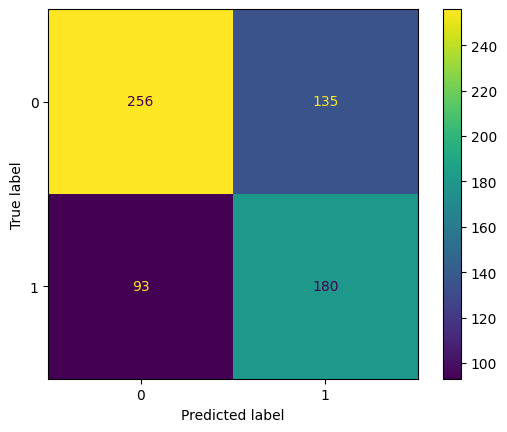

In [134]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr
)

plt.show()

Achieved an accuracy of 65.66% and a ROC-AUC of 0.713.
Identified 66% of churned customers (high recall), making it effective for retention campaigns.
Served as a strong and interpretable baseline model for comparison.

In [135]:
print(results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.6566265060240963, 'Precision': 0.5714285714285714, 'Recall': 0.6593406593406593, 'F1 Score': 0.6122448979591837, 'ROC-AUC': np.float64(0.7131427821964906)}]


2.RANDOM FOREST

In [129]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [136]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.68      0.70      0.69       391
           1       0.55      0.53      0.54       273

    accuracy                           0.63       664
   macro avg       0.61      0.61      0.61       664
weighted avg       0.63      0.63      0.63       664



In [139]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

ROC-AUC: 0.6856608864281498


In [140]:
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
})

Achieved an accuracy of 63%, which was lower than Logistic Regression.
Performance decreased in terms of precision, recall, and F1-score for the churn class.
The default Random Forest did not capture customer behavior better than the simpler baseline mode

3.XGBOOST

In [146]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)


param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}



In [147]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='roc_auc', verbose=2)

In [148]:
print("Best Parameters:")
print(grid.best_params_)

print("Best CV ROC-AUC:")
print(grid.best_score_)

Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best CV ROC-AUC:
0.735346935438429


In [149]:
best_xgb = grid.best_estimator_

y_pred = best_xgb.predict(X_test)

y_prob = best_xgb.predict_proba(X_test)[:,1]

In [150]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.69      0.70       391
           1       0.58      0.60      0.59       273

    accuracy                           0.66       664
   macro avg       0.65      0.65      0.65       664
weighted avg       0.66      0.66      0.66       664



In [151]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.7242254761436347


In [163]:
print(grid.best_score_)

0.735346935438429


Hyperparameter tuning improved the model, increasing ROC-AUC to 0.724.
Achieved 66% accuracy with improved precision compared to the default model.
Selected as the final model because it demonstrated the best overall ability to distinguish between churned and active customers.

In [154]:
results.append({
    "Model": "XGboost",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
})

In [160]:
print(results)


[{'Model': 'Logistic Regression', 'Accuracy': 0.6566265060240963, 'Precision': 0.5714285714285714, 'Recall': 0.6593406593406593, 'F1 Score': 0.6122448979591837, 'ROC-AUC': np.float64(0.7131427821964906)}, {'Model': 'Random Forest', 'Accuracy': 0.6280120481927711, 'Precision': 0.5492424242424242, 'Recall': 0.5311355311355311, 'F1 Score': 0.5400372439478585, 'ROC-AUC': np.float64(0.6856608864281498)}, {'Model': 'XGboost', 'Accuracy': 0.6551204819277109, 'Precision': 0.5769230769230769, 'Recall': 0.6043956043956044, 'F1 Score': 0.590339892665474, 'ROC-AUC': np.float64(0.7242254761436347)}]


In [161]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Frequency,0.460546
1,Monetary,0.256609
2,UniqueProducts,0.132113
3,AvgOrderValue,0.091901
4,AvgItemsPerOrder,0.058830


In [164]:
import joblib
joblib.dump(best_xgb, "churn_prediction_model.pkl")

['churn_prediction_model.pkl']

In [166]:
loaded_model = joblib.load("churn_prediction_model.pkl")

In [168]:
loaded_model.predict_proba(X_test.iloc[:5])

array([[0.9110723 , 0.08892769],
       [0.8751975 , 0.12480244],
       [0.5015531 , 0.49844688],
       [0.900615  , 0.09938499],
       [0.85947514, 0.14052485]], dtype=float32)

**Observation**

Increase purchase frequency through loyalty programs.
Target high-risk customers with personalized retention campaigns.
Reward high-value customers using exclusive offers.
Promote product exploration through cross-selling and personalized recommendations.